## Partial run of the simulation

1. Get excitement from the provided FDM simulation data.
2. Cut the excitation data to only 1m, 5m and 10m rail length answers
3. Run simulation only with the vertical excitation component
4. Compare the results with the older simulation results
5. If the simulation looks good, then build total excitation
6. Run the simulation with the total excitation

If the results look good, ready to parallelize and run the full simulation with all the excitation components.

In [19]:
import numpy as np
from rolland.database.rail.db_rail import UIC60
from utils import interpolate_contour_2d, create_mesh, calculate_centre_and_area_triangles, calculate_projected_area, \
    assign_v_to_points

## Step 1
Get excitement from the provided FDM simulation data.

In [20]:
u_y_pos_1 = np.load('provided_data/u_y_exc_at_pos1.npy')
u_y_pos_2 = np.load('provided_data/u_y_exc_at_pos2.npy')
u_z_pos_1 = np.load('provided_data/u_z_exc_at_pos1.npy')
u_z_pos_2 = np.load('provided_data/u_z_exc_at_pos2.npy')
phi_x_pos1 = np.load('provided_data/phi_x_exc_at_pos1.npy')
phi_x_pos2 = np.load('provided_data/phi_x_exc_at_pos2.npy')

## Step 2
Create the rail mesh of monopoles

In [21]:
rail_geometry = UIC60.rl_geo
length = 65.6
rail_geometry = interpolate_contour_2d(rail_geometry, 25)
triangle_coords, triangle_index = create_mesh(rail_geometry,
                                              mesh_size=0.25,
                                              L=length #146.0
                                              )

A, centre, norm = calculate_centre_and_area_triangles(triangle_coords, triangle_index)
print(f'mean area = {A.mean()}')
projected_area = calculate_projected_area(A, norm, 1)

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 10%] Meshing curve 5 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 10%] Meshing curve 7 (Line)
Info    : [ 10%] Meshing curve 8 (Line)
Info    : [ 20%] Meshing curve 9 (Line)
Info    : [ 20%] Meshing curve 10 (Line)
Info    : [ 20%] Meshing curve 11 (Line)
Info    : [ 20%] Meshing curve 12 (Line)
Info    : [ 20%] Meshing curve 13 (Line)
Info    : [ 20%] Meshing curve 14 (Line)
Info    : [ 20%] Meshing curve 15 (Line)
Info    : [ 30%] Meshing curve 16 (Line)
Info    : [ 30%] Meshing curve 17 (Line)
Info    : [ 30%] Meshing curve 18 (Line)
Info    : [ 30%] Meshing curve 19 (Line)
Info    : [ 30%] Meshing curve 20 (Line)
Info    : [ 30%] Meshing curve 21 (Line)
Info    : [ 30%] Meshing curve 22 (Line)
Info    : [ 30%] Meshing curve 23 (Line)
Info    : [ 40%] Meshing curve 24 (Line)
I

Info    : [ 60%] Meshing surface 115 (Surface, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 119 (Surface, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 123 (Surface, Frontal-Delaunay)
Info    : [ 80%] Meshing surface 127 (Surface, Frontal-Delaunay)
Info    : [ 80%] Meshing surface 131 (Surface, Frontal-Delaunay)
Info    : [ 80%] Meshing surface 135 (Surface, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 139 (Surface, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 143 (Surface, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 147 (Surface, Frontal-Delaunay)
Info    : [100%] Meshing surface 151 (Surface, Frontal-Delaunay)
Info    : [100%] Meshing surface 152 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.259891s, CPU 0.217519s)
Info    : 6612 nodes 19895 elements
mean area = 0.0031566039654613905


## Step 3
Simulate only for the vertical excitation component of the vertical excitation

In [22]:
#fist we cut the excitation respond to the 5 meter that we need
#excitation point: 0.65*50 + 0.65/2
#The 5 meter that we want to simulate is excitation_point ± 2.5
#each discrete point is 0.05m, so we would need to cut the matrice from:
#(excitation_point - 2.5)/0.05 to (excitation_point + 2.5)/0.05

excitation_point = 0.65*50 + 0.65/2
start_index = int((excitation_point - (length/2)) / 0.05)
end_index = int((excitation_point + (length/2)) / 0.05)

print(f'excitation point = {excitation_point} '
      f'start_index = {start_index} '
      f'end_index = {end_index}')


excitation point = 32.825 start_index = 0 end_index = 1312


In [23]:
vert_exc_vert_resp = u_z_pos_1[0::2, start_index:end_index]
print(vert_exc_vert_resp.shape)

(50000, 1286)


In [ ]:
#get ready for the simulation:
#first step: fourier transformation:
import scipy as sp
f_sim_axis = sp.fft.fftfreq(vert_exc_vert_resp.shape[0], 0.5e-5)
print(f_sim_axis.shape)
vert_exc_vert_resp_v = sp.fft.fft(vert_exc_vert_resp, norm='forward', axis=0) * 2
print(vert_exc_vert_resp_v.shape)
omega = 2 * np.pi * f_sim_axis
vert_exc_vert_resp_v = (1j * omega[:, None]) * vert_exc_vert_resp_v
nx = vert_exc_vert_resp_v.shape[1]
dx = 0.05
x_axis = np.arange(nx) * dx + (start_index * 0.05)
print(f'nx: {nx} '
      f'dx: {dx} '
      f'starting_point: {start_index * 0.05}')
triangle_v_fd = assign_v_to_points(
    x_axis,
    vert_exc_vert_resp_v.T,
    centre
)
print(triangle_v_fd.max())

(50000,)
(50000, 1286)
nx: 1286 dx: 0.05 starting_point: 0.0


In [17]:
from utils import run_simulation_semi_circle
from frequency_domain import monopole_multi_fa__calcf__outf
semi_circle_centre = np.array((-0.71, -0.08, 35))
P = run_simulation_semi_circle(circle_centre=semi_circle_centre,
                               circle_radius=2.5,
                               number_of_points=10,
                               simulation_function=monopole_multi_fa__calcf__outf,
                               V_fd=triangle_v_fd,
                               freqs=f_sim_axis,
                               X=centre,
                               A=projected_area[:, None],)

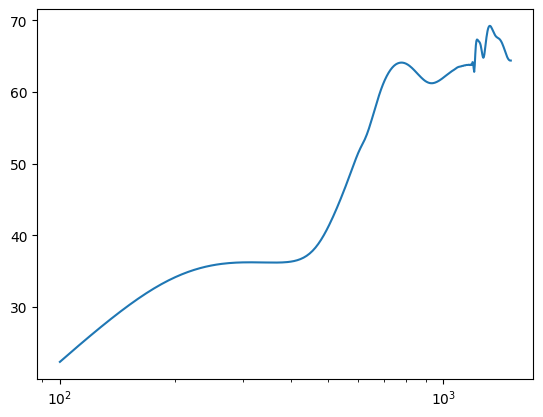

In [18]:
from matplotlib import pyplot as plt

p0 = 2e-5
P_db = 20 * np.log10((np.abs(P) + p0)/p0)
plt_mask = (f_sim_axis >= 100) & (f_sim_axis <= 1500)
plt_f_axis = f_sim_axis[plt_mask]
plt_P_db = P_db[plt_mask]
plt.plot(plt_f_axis, plt_P_db)
plt.xscale('log')
plt.show()